# 02. Base model

Hypothesis testing: is it possible to predict error positions based on the syndrome and mask?

In [26]:
import sys
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append('..')
from rs.channels import qsc_erasure_channel
from rs.dataset_gen import RSPositionDataset
from rs.model import BasePredictor, FocalLoss, count_parameters
from rs.training import train_model
from rs.evaluation import compare_decoders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [27]:
P_ERR = 0.02
P_ERASE_VALUES = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14]
TRAIN_SIZE = 50000
EPOCHS = 150

In [28]:
results = []

for p_erase in P_ERASE_VALUES:
    print(f"\n{'='*50}")
    print(f"p_erase = {p_erase}")
    print('='*50)
    
    print('Generating dataset...')
    dataset = RSPositionDataset(TRAIN_SIZE, P_ERR, p_erase)
    
    print('Training model...')
    model = BasePredictor().to(device)
    criterion = nn.BCEWithLogitsLoss()
    
    train_model(model, dataset, criterion, epochs=EPOCHS, 
                device=device, log_every=50)
    print('Training finished.')
    
    r = compare_decoders(model, qsc_erasure_channel, P_ERR, p_erase,
                         threshold=0.3, num_samples=1000, device=device)
    
    r['p_erase'] = p_erase
    results.append(r)
    
    print(f"Classic:      {r['classic']:.1%}")
    print(f"Hybrid:       {r['hybrid']:.1%}")
    print(f"Classic+hint: {r['classic_hint']:.1%}")


p_erase = 0.02
Generating dataset...
Training model...
Epoch  50/150, Loss: 0.0991
Epoch 100/150, Loss: 0.0808
Epoch 150/150, Loss: 0.0732
Training finished.
Classic:      97.6%
Hybrid:       94.1%
Classic+hint: 100.0%

p_erase = 0.04
Generating dataset...
Training model...
Epoch  50/150, Loss: 0.1152
Epoch 100/150, Loss: 0.0969
Epoch 150/150, Loss: 0.0885
Training finished.
Classic:      60.7%
Hybrid:       83.1%
Classic+hint: 98.0%

p_erase = 0.06
Generating dataset...
Training model...
Epoch  50/150, Loss: 0.1287
Epoch 100/150, Loss: 0.1102
Epoch 150/150, Loss: 0.0998
Training finished.
Classic:      19.6%
Hybrid:       64.2%
Classic+hint: 90.1%

p_erase = 0.08
Generating dataset...
Training model...
Epoch  50/150, Loss: 0.1422
Epoch 100/150, Loss: 0.1233
Epoch 150/150, Loss: 0.1102
Training finished.
Classic:      2.2%
Hybrid:       36.8%
Classic+hint: 62.6%

p_erase = 0.1
Generating dataset...
Training model...
Epoch  50/150, Loss: 0.1534
Epoch 100/150, Loss: 0.1332
Epoch 150/150

In [35]:
df = pd.DataFrame(results)
df = df[['p_erase', 'classic', 'hybrid', 'classic_hint']]
df.columns = ['p_erase', 'Classic', 'Hybrid (base)', 'Classic+hint']

df_display = df.copy()
for col in ['Classic', 'Hybrid (base)', 'Classic+hint']:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.1%}")

df.to_csv('model_base_results.csv', index=False)
print(df_display)

   p_erase Classic Hybrid (base) Classic+hint
0     0.02   97.6%         94.1%       100.0%
1     0.04   60.7%         83.1%        98.0%
2     0.06   19.6%         64.2%        90.1%
3     0.08    2.2%         36.8%        62.6%
4     0.10    0.1%         17.0%        35.1%
5     0.12    0.1%          3.7%        10.4%
6     0.14    0.0%          1.0%         1.7%


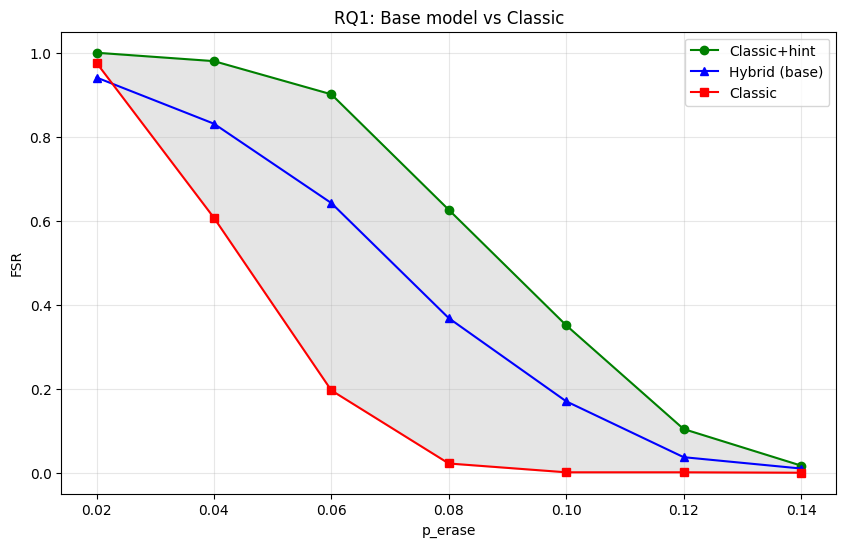

In [34]:
plt.figure(figsize=(10, 6))
p_vals = [r['p_erase'] for r in results]
plt.plot(p_vals, [r['classic_hint'] for r in results], 'g-o', label='Classic+hint')
plt.plot(p_vals, [r['hybrid'] for r in results], 'b-^', label='Hybrid (base)')
plt.plot(p_vals, [r['classic'] for r in results], 'r-s', label='Classic')
plt.fill_between(p_vals, [r['classic'] for r in results], 
                 [r['classic_hint'] for r in results], alpha=0.2, color='gray')
plt.xlabel('p_erase')
plt.ylabel('FSR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('RQ1: Base model vs Classic')
plt.savefig('model_base_comparison.png', dpi=150)
plt.show()

In [ ]:
idx = P_ERASE_VALUES.index(0.06)
r = results[idx]
gap_filled = (r['hybrid'] - r['classic']) / (r['classic_hint'] - r['classic'])
print(f"\nConclusion: when p_erase = 0.06, the baseline model fills {gap_filled: 0%} of the gap.")
print("We choose p_erase = 0.06 for further experiments.")


Вывод: при p_erase = 0.06 базовая модель заполняет 63% разрыва.
Выбираем p_erase = 0.06 для дальнейших экспериментов.
